# **GROVER ALGORITHM**

Grover's Algorithm adalah algoritman pencarian tak terstruktur yang berjala pada komputer kuantum dengan kompleksitas $ O\sqrt(N) $

### ***1. LIBRARY***

QuantumCircuit => untuk membangun circuit

Statevector => untuk melihat state mana yang amplitudonya paling besar setelah iterasi

AerSimulator => backend (tempat menjalankan) simulator modern

transpile => menyesuaikan circuit dengan backend

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorSampler
import matplotlib.pyplot as plt
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np

### ***2. INISIALISASI***

In [2]:
#inisialisasi
target ='1100100101'
n = len(target)
N = 2**n

print(f"n = {n}\nN = {N}")

n = 10
N = 1024


### ***3. MEMBUAT ORACLE CIRCUIT***

oracle berfungsi untuk membalik fase target: $$ O∣x⟩=(−1)^{f(x)}∣x⟩ $$ 

Namun oracle tidak merubah probabilitas, hanya merubah fase keadaan. Misal: 

$ ∣x⟩ = $ state basis (misalnya $ |000⟩ $, $ |101⟩ $, dll)

$ f(x) = $ fungsi yang mengecek apakah x target atau bukan (1 = kalau x adalah target, 0 = kalau bukan)

Sehingga, ketika $ f(x)=0 $ maka oracle akan berubah menjadi negatif


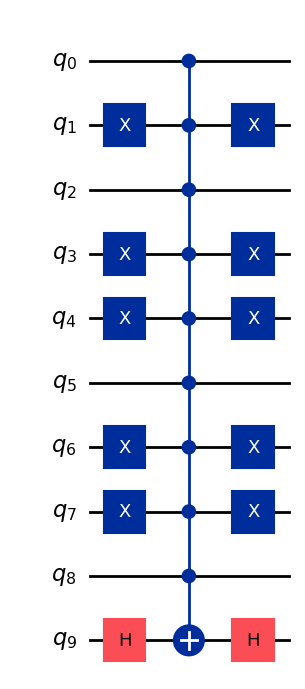

In [3]:
#oracle
def quantum_oracle(target):
    oracle = QuantumCircuit(n, name= 'Oracle')

    #menerapkan X-gate setiap menemukan |0>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            oracle.x(i)

    #menerapkan multi controlled Z-gate untuk setiap qubit
    oracle.h(n-1)
    oracle.mcx(list(range(n-1)), n-1)
    oracle.h(n-1)

    #menerapkan X-gate untuk menemukan |0>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            oracle.x(i)

    #membuat black box
    oracle.to_gate()

    return oracle

quantum_oracle(target).draw('mpl')
    

In [4]:
#inisialisasi circuit oracle
co = QuantumCircuit(n)
co.h(list(range(n)))
co.barrier()
co.append(quantum_oracle(target), list(range(n)))

co.draw('mpl')

#simulasi setelah keadaan awal bertemu dengan oracle
simulator = Aer.get_backend("statevector_simulator")
job = transpile(co, simulator)
result = simulator.run(job).result()
counts = result.get_counts(job)

#mengambil amplitudo setiap keadaan
statevector = result.get_statevector()

#menampilkan amplitudo setiap keadaan setelah oracle
for i, amp in enumerate(np.asarray(statevector)):
    print(f"Amplitude |{bin(i)[2:].zfill(len(target))}> : {amp:.2f}")

#plot_histogram(counts)

Amplitude |0000000000> : 0.03+0.00j
Amplitude |0000000001> : 0.03+0.00j
Amplitude |0000000010> : 0.03+0.00j
Amplitude |0000000011> : 0.03+0.00j
Amplitude |0000000100> : 0.03+0.00j
Amplitude |0000000101> : 0.03+0.00j
Amplitude |0000000110> : 0.03+0.00j
Amplitude |0000000111> : 0.03+0.00j
Amplitude |0000001000> : 0.03+0.00j
Amplitude |0000001001> : 0.03+0.00j
Amplitude |0000001010> : 0.03+0.00j
Amplitude |0000001011> : 0.03+0.00j
Amplitude |0000001100> : 0.03+0.00j
Amplitude |0000001101> : 0.03+0.00j
Amplitude |0000001110> : 0.03+0.00j
Amplitude |0000001111> : 0.03+0.00j
Amplitude |0000010000> : 0.03+0.00j
Amplitude |0000010001> : 0.03+0.00j
Amplitude |0000010010> : 0.03+0.00j
Amplitude |0000010011> : 0.03+0.00j
Amplitude |0000010100> : 0.03+0.00j
Amplitude |0000010101> : 0.03+0.00j
Amplitude |0000010110> : 0.03+0.00j
Amplitude |0000010111> : 0.03+0.00j
Amplitude |0000011000> : 0.03+0.00j
Amplitude |0000011001> : 0.03+0.00j
Amplitude |0000011010> : 0.03+0.00j
Amplitude |0000011011> : 0.0

### ***4. DIFFUSION OPERATOR***

Diffusion berfungsi untuk merotasikan keadaan awal sebanyak $\theta$ agar mendekati target. $$ \theta = 2\arcsin(1/(\sqrt(N)) $$

Kalau dihitung dari example,

In [5]:
theta = 2*np.arcsin(1/(np.sqrt(N)))
print(f"theta = {np.degrees(theta):.2f}°")
print(f"theta = {theta/np.pi:.6f} π rad")


theta = 3.58°
theta = 0.019898 π rad


untuk melengkapi circuit, butuh mengimplementasikan reflection $$ U_s = 2∣x⟩⟨x∣ - \mathbb{I} $$

berfungsi untuk membalik setiap keadaan. misal: $ ∣0⟩ => ⟨s∣ $

maka bentuk circuit lengkapnya:
$$ H^{\otimes}U_0H^{\otimes n} = U_s $$

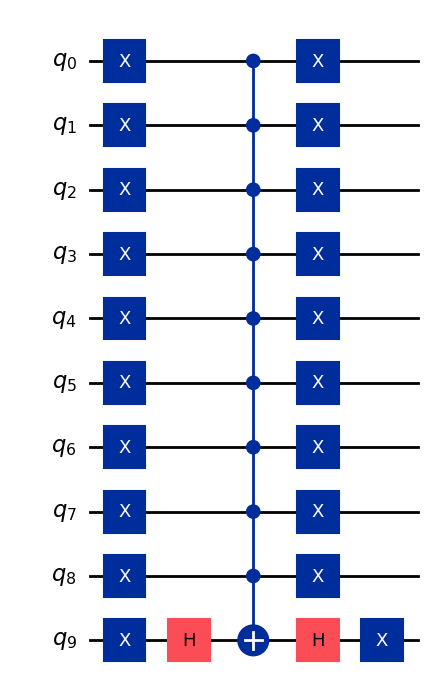

In [6]:
#circuit duffusion
def quantum_diffusion(target):
    dif = QuantumCircuit(len(target), name='Diffusion')

    #X-gate untuk semua qubit
    dif.x(list(range(len(target))))

    #menerapkan multi controlled Z-gate untuk semua qubit
    dif.h(len(target)-1)
    dif.mcx(list(range(len(target)-1)), len(target)-1)
    dif.h(len(target)-1)

    #menerapkan X-gate untuk menemukan |0>
    dif.x(list(range(len(target))))

    #membuat black box
    #oracle.to_gate()

    return dif

quantum_diffusion(target).draw('mpl')


### ***5. MENGGABUNGKAN CIRCUIT ORACLE & DIFFUSION***

Amplitude |0000000000> : -0.03-0.00j
Amplitude |0000000001> : -0.03-0.00j
Amplitude |0000000010> : -0.03-0.00j
Amplitude |0000000011> : -0.03-0.00j
Amplitude |0000000100> : -0.03-0.00j
Amplitude |0000000101> : -0.03-0.00j
Amplitude |0000000110> : -0.03-0.00j
Amplitude |0000000111> : -0.03-0.00j
Amplitude |0000001000> : -0.03-0.00j
Amplitude |0000001001> : -0.03-0.00j
Amplitude |0000001010> : -0.03-0.00j
Amplitude |0000001011> : -0.03-0.00j
Amplitude |0000001100> : -0.03-0.00j
Amplitude |0000001101> : -0.03-0.00j
Amplitude |0000001110> : -0.03-0.00j
Amplitude |0000001111> : -0.03-0.00j
Amplitude |0000010000> : -0.03-0.00j
Amplitude |0000010001> : -0.03-0.00j
Amplitude |0000010010> : -0.03-0.00j
Amplitude |0000010011> : -0.03-0.00j
Amplitude |0000010100> : -0.03-0.00j
Amplitude |0000010101> : -0.03-0.00j
Amplitude |0000010110> : -0.03-0.00j
Amplitude |0000010111> : -0.03-0.00j
Amplitude |0000011000> : -0.03-0.00j
Amplitude |0000011001> : -0.03-0.00j
Amplitude |0000011010> : -0.03-0.00j
A

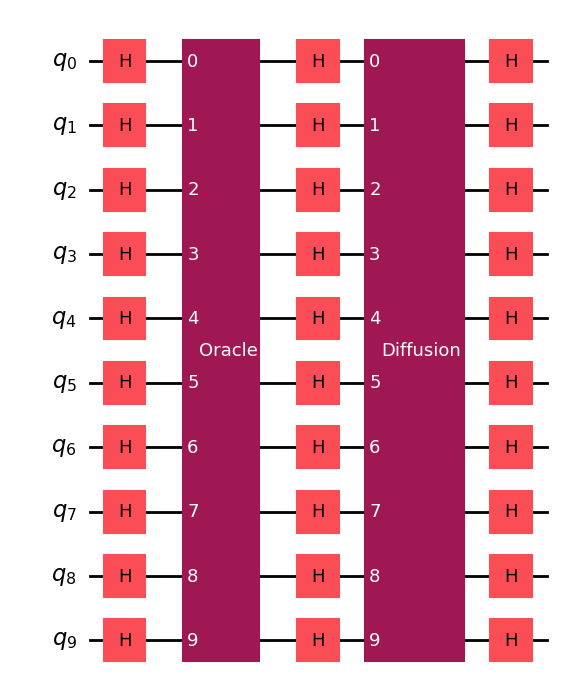

In [7]:
#inisialisasi
gc = QuantumCircuit(n)
gc.h(list(range(n)))

#menerapkan oracle & diffusion
gc.append(quantum_oracle(target), list(range(n)))
gc.h(list(range(n)))
gc.append(quantum_diffusion(target), list(range(n)))
gc.h(list(range(n)))

#simulasi
simulator = Aer.get_backend("statevector_simulator")
job = transpile(gc, simulator)
result = simulator.run(job).result()

#ambil amplitudo setiap keadaan
statevector = result.get_statevector()

#menampilkan amplitudo setelah oracle & diffusion
for i, amp in enumerate(np.asarray(statevector)):
    print(f"Amplitude |{bin(i)[2:].zfill(n)}> : {amp:.2f}")

gc.draw('mpl')



### ***6. MEASUREMENT AKHIR***

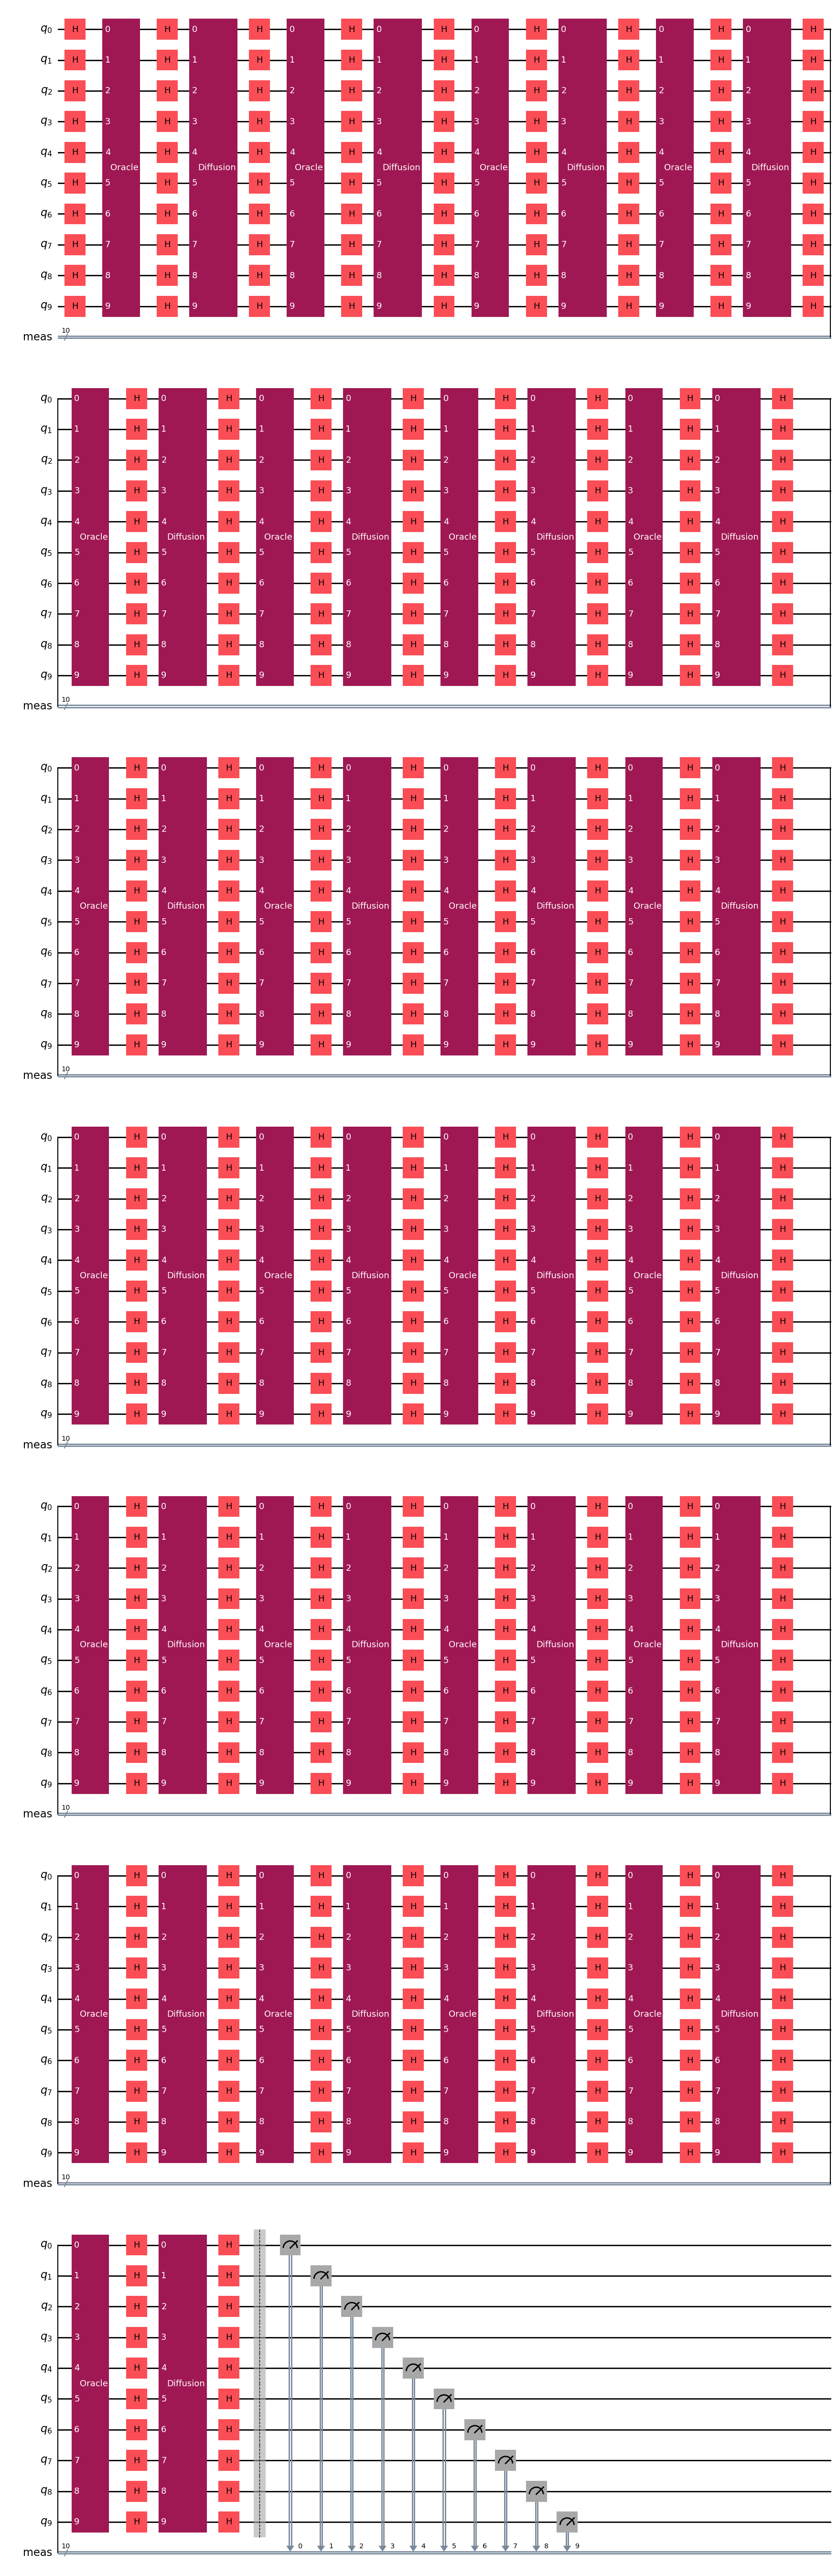

In [8]:
#menambahkan meas ke dalam circuit
gc = QuantumCircuit(n)
gc.h(range(n))

#iterasi optimal
optimal = int((np.pi/4)*np.sqrt(N))
for _ in range(optimal):
    gc.append(quantum_oracle(target), list(range(n)))
    gc.h(list(range(n)))
    gc.append(quantum_diffusion(target), list(range(n)))
    gc.h(list(range(n)))

#mengukur semua keadaan
gc.measure_all()

#menghitung probabilitas
simulator = Aer.get_backend("statevector_simulator")
job = simulator.run(transpile(gc, simulator))
result = job.result()
statevector = result.get_statevector()
target_prob = abs(statevector[int(target, 2)])**2

gc.draw('mpl')


In [9]:
print(f"|{target}> ditemukan! Membutuhkan {optimal} iterasi supaya optimal")
print(f"Dengan probabilitas target = {target_prob*100:.2f}%")

|1100100101> ditemukan! Membutuhkan 25 iterasi supaya optimal
Dengan probabilitas target = 100.00%


<function matplotlib.pyplot.show(close=None, block=None)>

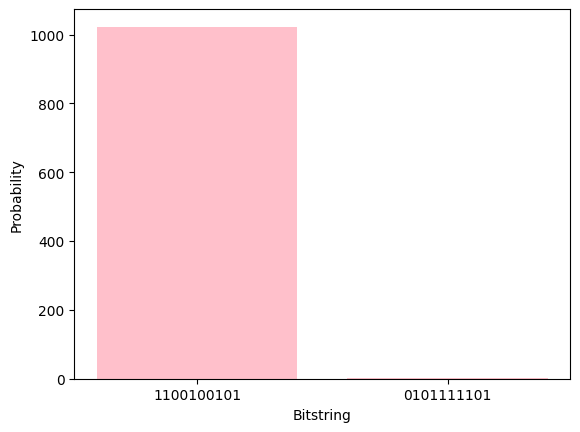

In [10]:
sampler = StatevectorSampler()
job = sampler.run([gc])
result = job.result()

quasi_dist = result[0].data.meas.get_counts()
counts = {bitstring: int(count) for bitstring, count in quasi_dist.items()}

plt.bar(counts.keys(), counts.values(), color='pink')
plt.xlabel('Bitstring')
plt.ylabel('Probability')
plt.show